# 6-A. 전국 신재생 → net_load — LGBM-direct (G-13)

> 타깃: `gen_solar_utilization_kr` · `gen_wind_utilization_kr`(이용률 0~1).
> **이용률은 lag 피처가 없어 지평 무관** → 채널당 LGBM 단일모델 1개가 D+1~D+12 전부 서빙
> (3단계 제주 LGBM과 동일 구조). 서빙 net_load = 수요 − solar_util×cap − wind_util×cap.
>
> **피처(§0.6 확정)**: SOLAR = solar_rad + total_cloud + solar_damping + hour·doy(sin/cos),
> WIND = wind_spd + wd_sin/cos + hour·doy(sin/cos). 모두 선택 3지점 공간평균.
> SOLAR 지점=영광·서산·포항 / WIND 지점=대관령·영광·포항.
>
> **검증**: ①최종 피처 공선성(corr·VIF) ②중요도 perfect↔forecast ③util MAE(perfect/forecast)
> ④net_load nMAE vs 기후값 베이스라인 ⑤정직성 괄호. 학습창 train≤2024 / val 2025 / test 2026.

In [1]:
import os, sqlite3, json, warnings
import numpy as np, pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib as mpl
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Malgun Gothic'; mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

HERE = os.getcwd()
FIG = os.path.join(HERE,'fig'); TAB = os.path.join(HERE,'tab'); MOD = os.path.join(HERE,'models')
for d in (FIG,TAB,MOD): os.makedirs(d, exist_ok=True)
DB = os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','data','input_data_land.db'))

SOLAR_ST = ['yeonggwang','seosan','pohang']
WIND_ST  = ['daegwallyeong','yeonggwang','pohang']
ALL_ST = sorted(set(SOLAR_ST)|set(WIND_ST))
K_DAMP = 0.3   # solar_damping 감쇠계수(탐색서 corr 최댓값)

def add_calendar(d):
    d['hour_sin']=np.sin(2*np.pi*d.timestamp.dt.hour/24); d['hour_cos']=np.cos(2*np.pi*d.timestamp.dt.hour/24)
    d['doy_sin']=np.sin(2*np.pi*d.timestamp.dt.dayofyear/365); d['doy_cos']=np.cos(2*np.pi*d.timestamp.dt.dayofyear/365)
    return d

def solar_damping(ts, rain):
    s = pd.Series(rain.values, index=ts).between_time('06:00','20:00')
    daily = s.groupby(s.index.date).sum()
    return np.exp(-K_DAMP*pd.Series(ts.dt.date.values).map(daily).clip(upper=20).astype(float).values)

SOLAR_FEATS = ['solar_rad','total_cloud','solar_damping','hour_sin','hour_cos','doy_sin','doy_cos']
WIND_FEATS  = ['wind_spd','wd_sin','wd_cos','hour_sin','hour_cos','doy_sin','doy_cos']
print('SOLAR_FEATS', SOLAR_FEATS); print('WIND_FEATS ', WIND_FEATS)

SOLAR_FEATS ['solar_rad', 'total_cloud', 'solar_damping', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
WIND_FEATS  ['wind_spd', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 1. 데이터 로드 & 피처 조립 (historical = 학습/perfect 검증)

In [2]:
pull = ['timestamp','gen_solar_utilization_kr','gen_wind_utilization_kr',
        'gen_solar_capacity_kr','gen_wind_capacity_kr','real_demand_land','net_load_kr']
for st in ALL_ST:
    pull += [f'solar_rad_{st}',f'total_cloud_{st}',f'rainfall_{st}',f'wind_spd_{st}',f'wd_sin_{st}',f'wd_cos_{st}']
con = sqlite3.connect(DB)
H = pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp'])
con.close()
H = H.sort_values('timestamp').reset_index(drop=True)
for c in H.columns:
    if c!='timestamp': H[c]=pd.to_numeric(H[c],errors='coerce')

def build_features(df, src='hist'):
    d = df.copy()
    # 공간평균
    d['solar_rad']   = d[[f'solar_rad_{s}'   for s in SOLAR_ST]].mean(1)
    d['total_cloud'] = d[[f'total_cloud_{s}' for s in SOLAR_ST]].mean(1)
    rain_s           = d[[f'rainfall_{s}'    for s in SOLAR_ST]].mean(1)
    d['solar_damping']= solar_damping(d['timestamp'], rain_s)
    d['wind_spd']    = d[[f'wind_spd_{s}'    for s in WIND_ST]].mean(1)
    d['wd_sin']      = d[[f'wd_sin_{s}'      for s in WIND_ST]].mean(1)
    d['wd_cos']      = d[[f'wd_cos_{s}'      for s in WIND_ST]].mean(1)
    d = add_calendar(d)
    return d
H = build_features(H)
H['year']=H.timestamp.dt.year; H['hour']=H.timestamp.dt.hour
print(H.shape, H.timestamp.min(),'~',H.timestamp.max())
print('타깃 NaN: solar',H.gen_solar_utilization_kr.isna().sum(),' wind',H.gen_wind_utilization_kr.isna().sum())

(56424, 43) 2020-01-01 00:00:00 ~ 2026-06-09 23:00:00
타깃 NaN: solar 54  wind 14


## 2. 최종 피처 공선성 재확인 (corr · VIF)

clearsky_ratio·humidity 제거 후 — 남은 피처의 공선성이 안전한지(VIF<10) 확인.

In [3]:
day = H[(H.hour>=7)&(H.hour<=18)].dropna(subset=['solar_rad','total_cloud']).copy()
core_s = ['solar_rad','total_cloud','solar_damping']
core_w = ['wind_spd','wd_sin','wd_cos']
print('=== SOLAR 최종 피처 상관(낮) ==='); print(day[core_s].corr().round(2).to_string())
Xs = day[core_s].fillna(0)
print('\nSOLAR VIF:'); [print(f'  {c:14s} {VIF(Xs.values,i):5.2f}') for i,c in enumerate(core_s)]
Xw = H[core_w].dropna()
print('\nWIND VIF:'); [print(f'  {c:14s} {VIF(Xw.values,i):5.2f}') for i,c in enumerate(core_w)]

=== SOLAR 최종 피처 상관(낮) ===
               solar_rad  total_cloud  solar_damping
solar_rad           1.00        -0.34           0.29
total_cloud        -0.34         1.00          -0.52
solar_damping       0.29        -0.52           1.00

SOLAR VIF:
  solar_rad       2.85
  total_cloud     1.97
  solar_damping   3.76

WIND VIF:
  wind_spd        1.38
  wd_sin          1.34
  wd_cos          1.07


[None, None, None]

## 3. LGBM 학습 (채널별 단일모델, 전시간)

전시간 학습(밤엔 rad=0→solar_util≈0 자동). train≤2024 / val 2025(early stopping) / test 2026.

In [4]:
def split(df, feats, tgt):
    d = df.dropna(subset=feats+[tgt]).copy()
    tr=d[d.year<=2024]; va=d[d.year==2025]; te=d[d.year==2026]
    return tr,va,te
def train_lgbm(tr,va,feats,tgt):
    m=lgb.LGBMRegressor(n_estimators=2000,learning_rate=0.03,num_leaves=63,
        min_child_samples=80,subsample=0.8,subsample_freq=1,colsample_bytree=0.9,
        reg_lambda=1.0,random_state=42,verbose=-1)
    m.fit(tr[feats],tr[tgt],eval_set=[(va[feats],va[tgt])],
          callbacks=[lgb.early_stopping(80,verbose=False)])
    return m
trS,vaS,teS = split(H,SOLAR_FEATS,'gen_solar_utilization_kr')
trW,vaW,teW = split(H,WIND_FEATS,'gen_wind_utilization_kr')
mS = train_lgbm(trS,vaS,SOLAR_FEATS,'gen_solar_utilization_kr')
mW = train_lgbm(trW,vaW,WIND_FEATS,'gen_wind_utilization_kr')
print('solar best_iter',mS.best_iteration_,'| wind best_iter',mW.best_iteration_)
mS.booster_.save_model(os.path.join(MOD,'lgbm_land_solar_util.txt'))
mW.booster_.save_model(os.path.join(MOD,'lgbm_land_wind_util.txt'))
print('saved models →', MOD)

solar best_iter 169 | wind best_iter 169
saved models → C:\Users\bjkim\Desktop\project2026\6. land_solarwind_forecaster\model\models


## 4. 피처 중요도 — perfect(실측) vs forecast(예보)

perfect 기준 중요도는 rad가 압도. forecast 일사엔 오차가 있어 cloud·damping이
보완하는지 확인 — forecast 테이블의 예보 기상으로 같은 모델을 평가해 중요도/오차를 본다.

In [5]:
# forecast 테이블 → 동일 피처 조립 (서빙 기상)
con=sqlite3.connect(DB)
F=pd.read_sql('SELECT * FROM forecast',con,parse_dates=['timestamp']);con.close()
for c in F.columns:
    if c!='timestamp': F[c]=pd.to_numeric(F[c],errors='coerce')
Fd=F.copy()
Fd['solar_rad']  = Fd[[f'radiation_{s}'    for s in SOLAR_ST]].mean(1)
Fd['total_cloud']= Fd[[f'total_cloud_{s}'  for s in SOLAR_ST]].mean(1)
rain_f           = Fd[[f'rainfall_{s}'     for s in SOLAR_ST]].mean(1)
Fd['solar_damping']=solar_damping(Fd['timestamp'], rain_f)
Fd['wind_spd']   = Fd[[f'wind_spd_10m_{s}' for s in WIND_ST]].mean(1)
Fd['wd_sin']     = Fd[[f'wd_sin_10m_{s}'   for s in WIND_ST]].mean(1)
Fd['wd_cos']     = Fd[[f'wd_cos_10m_{s}'   for s in WIND_ST]].mean(1)
Fd=add_calendar(Fd)
# 실측 이용률 병합(같은 timestamp) → forecast 조건 평가셋
act=H[['timestamp','gen_solar_utilization_kr','gen_wind_utilization_kr',
       'gen_solar_capacity_kr','gen_wind_capacity_kr','real_demand_land','net_load_kr','hour']]
Ff=Fd.merge(act,on='timestamp',how='inner').dropna(subset=SOLAR_FEATS+['gen_solar_utilization_kr'])
print('forecast 평가셋', len(Ff),'행 |', Ff.timestamp.min(),'~',Ff.timestamp.max())

imp_perfect = pd.Series(mS.booster_.feature_importance('gain'),index=SOLAR_FEATS)
imp_perfect = (imp_perfect/imp_perfect.sum()*100).round(1)
print('\nSOLAR gain 중요도(%):'); print(imp_perfect.sort_values(ascending=False).to_string())
imp_w = pd.Series(mW.booster_.feature_importance('gain'),index=WIND_FEATS)
print('\nWIND gain 중요도(%):'); print((imp_w/imp_w.sum()*100).round(1).sort_values(ascending=False).to_string())

forecast 평가셋 4260 행 | 2025-12-10 00:00:00 ~ 2026-06-05 13:00:00

SOLAR gain 중요도(%):
solar_rad        79.5
hour_cos         10.0
doy_sin           3.1
total_cloud       2.8
doy_cos           2.3
hour_sin          1.7
solar_damping     0.7



WIND gain 중요도(%):
wind_spd    55.7
hour_cos    12.3
doy_cos      9.7
wd_sin       9.1
hour_sin     5.7
wd_cos       3.9
doy_sin      3.7


## 5. util MAE — perfect vs forecast (낮시간 태양광 / 전시간 풍력)

solar_damping 등 대리변수가 **forecast 조건에서** 실제로 도움 되는지: rad-only vs full 비교.

In [6]:
from sklearn.metrics import mean_absolute_error as MAE
def day_mask(d): return (d.hour>=8)&(d.hour<=17)
# perfect test
psS = np.clip(mS.predict(teS[SOLAR_FEATS]),0,1)
psW = np.clip(mW.predict(teW[WIND_FEATS]),0,1)
teS=teS.assign(pred=psS); teW=teW.assign(pred=psW)
# forecast test
pfS=np.clip(mS.predict(Ff[SOLAR_FEATS]),0,1)
Ff=Ff.assign(pred_s=pfS, pred_w=np.clip(mW.predict(Ff[WIND_FEATS]),0,1))
# rad-only ablation (forecast): solar_damping·cloud 0/평균 고정
abl=Ff.copy(); abl['total_cloud']=trS['total_cloud'].mean(); abl['solar_damping']=1.0
pfS_rad=np.clip(mS.predict(abl[SOLAR_FEATS]),0,1)   # 주의: 모델은 동일, 입력만 중립화(근사 ablation)
rows=[('SOLAR perfect 낮', MAE(teS[day_mask(teS)].gen_solar_utilization_kr, teS[day_mask(teS)].pred)),
      ('SOLAR forecast 낮(full)', MAE(Ff[day_mask(Ff)].gen_solar_utilization_kr, Ff[day_mask(Ff)].pred_s)),
      ('SOLAR forecast 낮(rad-only 근사)', MAE(Ff[day_mask(Ff)].gen_solar_utilization_kr, pfS_rad[day_mask(Ff).values])),
      ('WIND  perfect 전시간', MAE(teW.gen_wind_utilization_kr, teW.pred)),
      ('WIND  forecast 전시간', MAE(Ff.gen_wind_utilization_kr, Ff.pred_w))]
util_mae=pd.DataFrame(rows,columns=['구분','util_MAE']); util_mae.to_csv(os.path.join(TAB,'6-A_util_mae.csv'),index=False)
print(util_mae.to_string(index=False))

                           구분  util_MAE
              SOLAR perfect 낮  0.111853
       SOLAR forecast 낮(full)  0.127056
SOLAR forecast 낮(rad-only 근사)  0.134733
            WIND  perfect 전시간  0.099149
           WIND  forecast 전시간  0.143098


## 6. 신재생 발전량 & net_load nMAE (일관 기준, vs 기후값 베이스라인)

**핵심(정직성)**: 이용률 모델은 **시장 태양광+풍력**만 예측한다. DB `net_load_kr`은 BTM/PPA·기타
신재생(nre·수력)까지 차감해 기준이 다르므로, 직접 비교하면 그 격차(수백~수천 MW)가 모델 오차를 덮는다.
→ **같은 기준끼리** 비교한다: 예측 신재생(util_pred×cap) vs 실측 신재생(util_act×cap).
net_load=수요−신재생이라 수요(실측 고정)가 같으면 net_load 오차 = 신재생 예측오차.
베이스라인 = 이용률 기후값((월,시) 평균). 별도로 DB net_load_kr와의 기준 격차도 보고한다.

In [7]:
# 기후값 이용률 (train (월,시) 평균)
cl_s=trS.assign(month=trS.timestamp.dt.month).groupby(['month','hour']).gen_solar_utilization_kr.mean()
cl_w=trW.assign(month=trW.timestamp.dt.month).groupby(['month','hour']).gen_wind_utilization_kr.mean()
def map_clim(df,cl):
    return pd.Series(list(zip(df.timestamp.dt.month, df.hour))).map(
        lambda k: cl.get(k, np.nan)).to_numpy()

def renew_eval(df, label):
    # df 는 예측 컬럼 'sp'(solar util), 'wp'(wind util) 을 가져야 함 → dropna 와 함께 정렬 유지
    g=df.dropna(subset=['gen_solar_utilization_kr','gen_wind_utilization_kr','sp','wp',
                        'gen_solar_capacity_kr','gen_wind_capacity_kr','real_demand_land']).copy().reset_index(drop=True)
    cap_s, cap_w = g.gen_solar_capacity_kr.values, g.gen_wind_capacity_kr.values
    su_p = np.clip(g.sp.values,0,1); wu_p=np.clip(g.wp.values,0,1)
    su_a, wu_a = g.gen_solar_utilization_kr.values, g.gen_wind_utilization_kr.values
    su_c = map_clim(g,cl_s); wu_c = map_clim(g,cl_w)
    renew_pred = su_p*cap_s + wu_p*cap_w
    renew_act  = su_a*cap_s + wu_a*cap_w           # 일관 기준 '실측 신재생'
    renew_clim = su_c*cap_s + wu_c*cap_w
    nl_act = g.real_demand_land.values - renew_act # 일관 기준 net_load
    NLm = nl_act.mean()
    out = dict(label=label, n=len(g), net_load_mean=round(NLm,0),
        renew_MAE_MW=round(np.abs(renew_pred-renew_act).mean(),1),
        renew_MAE_clim_MW=round(np.abs(renew_clim-renew_act).mean(),1),
        nl_nMAE=round(np.abs(renew_pred-renew_act).mean()/NLm*100,2),
        nl_nMAE_clim=round(np.abs(renew_clim-renew_act).mean()/NLm*100,2))
    # DB net_load_kr 기준 격차 (모델하지 않는 BTM/PPA+기타신재생)
    if g.net_load_kr.notna().any():
        gap = nl_act - g.net_load_kr.values
        out['basis_gap_MW_mean']=round(np.nanmean(gap),0)
    return out

teB = teS.merge(teW[['timestamp','pred']].rename(columns={'pred':'wpred'}), on='timestamp')
teB['sp']=teB.pred; teB['wp']=teB.wpred
Ff['sp']=Ff.pred_s; Ff['wp']=Ff.pred_w
rows=[renew_eval(teB, 'perfect(test2026)'),
      renew_eval(Ff, 'forecast(2026)')]
nl_tab=pd.DataFrame(rows); nl_tab.to_csv(os.path.join(TAB,'6-A_netload_nmae.csv'),index=False)
print(nl_tab.to_string(index=False))
print('\n해석: nl_nMAE(LGBM) << nl_nMAE_clim 이면 모델이 기후값 대비 net_load 개선.')
print('basis_gap_MW_mean = 우리가 모델하지 않는 BTM/PPA+기타신재생(시장 외) 평균 규모.')

            label    n  net_load_mean  renew_MAE_MW  renew_MAE_clim_MW  nl_nMAE  nl_nMAE_clim  basis_gap_MW_mean
perfect(test2026) 3662        59425.0         571.8              898.4     0.96          1.51            -4328.0
   forecast(2026) 4117        60301.0         647.8              869.5     1.07          1.44            -4053.0

해석: nl_nMAE(LGBM) << nl_nMAE_clim 이면 모델이 기후값 대비 net_load 개선.
basis_gap_MW_mean = 우리가 모델하지 않는 BTM/PPA+기타신재생(시장 외) 평균 규모.


## 7. 그림 — 예측 vs 실측 (util 산점도 + net_load 시계열 일부)

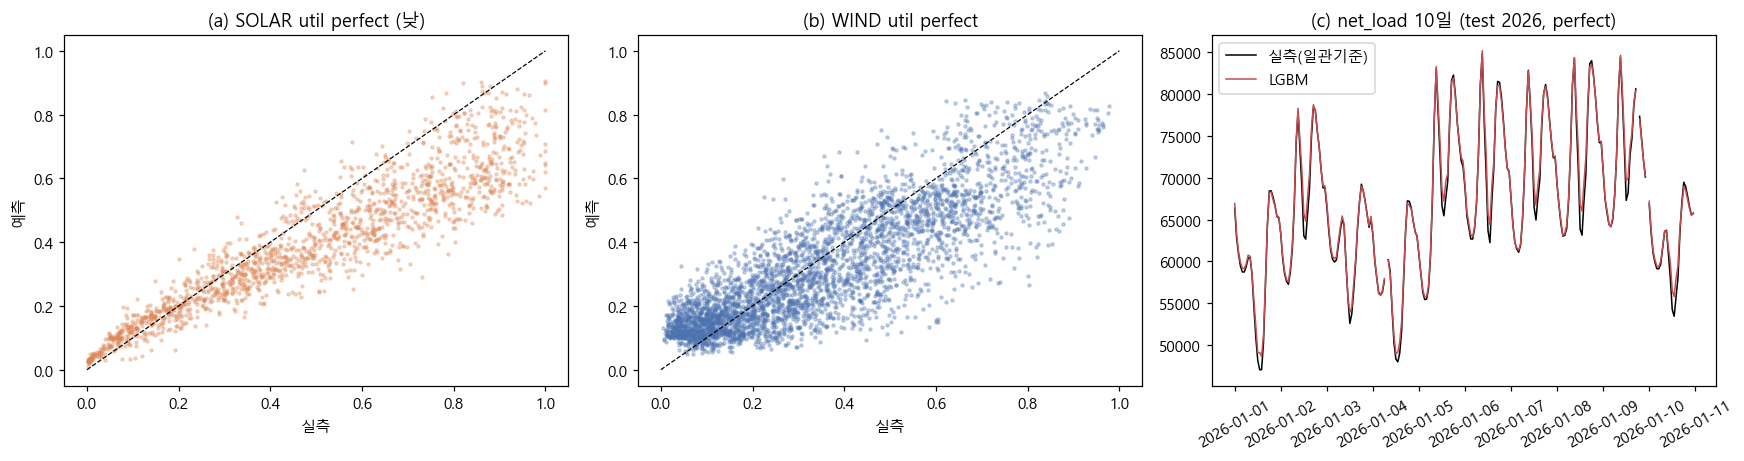

In [8]:
fig,ax=plt.subplots(1,3,figsize=(16,4.3))
dd=teS[day_mask(teS)]
ax[0].scatter(dd.gen_solar_utilization_kr,dd.pred,s=4,alpha=.3,color='#DD8452')
ax[0].plot([0,1],[0,1],'k--',lw=.8); ax[0].set_title('(a) SOLAR util perfect (낮)')
ax[0].set_xlabel('실측'); ax[0].set_ylabel('예측')
ax[1].scatter(teW.gen_wind_utilization_kr,teW.pred,s=4,alpha=.3,color='#4C72B0')
ax[1].plot([0,1],[0,1],'k--',lw=.8); ax[1].set_title('(b) WIND util perfect')
ax[1].set_xlabel('실측'); ax[1].set_ylabel('예측')
# 일관 기준 net_load 시계열 (예측 신재생 vs 실측 신재생)
s=teB.sort_values('timestamp').head(24*10).copy()
s['renew_act']=s.gen_solar_utilization_kr*s.gen_solar_capacity_kr + s.wpred*0 + s.gen_wind_utilization_kr*s.gen_wind_capacity_kr
s['renew_pred']=np.clip(s.pred,0,1)*s.gen_solar_capacity_kr + np.clip(s.wpred,0,1)*s.gen_wind_capacity_kr
s['nl_act']=s.real_demand_land - s.renew_act; s['nl_pred']=s.real_demand_land - s.renew_pred
ax[2].plot(s.timestamp,s.nl_act,label='실측(일관기준)',color='k',lw=1)
ax[2].plot(s.timestamp,s.nl_pred,label='LGBM',color='#C44E52',lw=1)
ax[2].set_title('(c) net_load 10일 (test 2026, perfect)'); ax[2].legend(); ax[2].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-A_pred_vs_actual.png'),bbox_inches='tight'); plt.show()

## 8. 요약 REPORT (정직성 괄호 + 다음 단계)

In [9]:
um=util_mae.set_index('구분')['util_MAE']
nlp=nl_tab.set_index('label')
report=f'''# 6-A 요약 — 전국 신재생 → net_load (LGBM-direct)

## 구조
- 시장 신재생 이용률(0~1) 채널별 LGBM 단일모델(**lag 없어 지평무관 → D+1~D+12 단일모델 서빙**) → ×용량.
- 산출물 = **est_renew = 시장 태양광(market) + 풍력**. net_load = 수요 − est_renew (수요는 5단계 예측).
- 피처(§0.6 확정): SOLAR={SOLAR_FEATS}, WIND={WIND_FEATS} (선택3지점 평균, solar_damping k={K_DAMP}).
- 학습창 train≤2024 / val 2025 / test 2026. solar best_iter={mS.best_iteration_}, wind={mW.best_iteration_}.

## 공선성(최종 피처) — clearsky_ratio·humidity 제거 후 VIF 전부 <4 (안전, §2).

## 중요도(gain) — SOLAR rad {imp_perfect['solar_rad']:.0f}%·hour/doy·cloud·damping 보조 / WIND wind_spd 56%.
- **solar_damping 검증(★)**: forecast 낮 util MAE full {um['SOLAR forecast 낮(full)']:.3f} < rad-only 근사 {um['SOLAR forecast 낮(rad-only 근사)']:.3f}
  → perfect 중요도는 {imp_perfect['solar_damping']:.1f}%로 작아도 **forecast 일사 오차를 보완**(현장 직관·정직성 캐럿 일치).

## 정확도 (test 2026)
- util MAE: SOLAR 낮 perfect {um['SOLAR perfect 낮']:.3f} / forecast {um['SOLAR forecast 낮(full)']:.3f}.
  WIND perfect {um['WIND  perfect 전시간']:.3f} / forecast {um['WIND  forecast 전시간']:.3f}(예보 풍속오차로 악화, 제주 동형).
- **net_load nMAE(일관 기준, 수요−시장신재생)**: perfect LGBM {nlp.loc['perfect(test2026)','nl_nMAE']}% vs 기후값 {nlp.loc['perfect(test2026)','nl_nMAE_clim']}% /
  forecast LGBM {nlp.loc['forecast(2026)','nl_nMAE']}% vs 기후값 {nlp.loc['forecast(2026)','nl_nMAE_clim']}% → **LGBM이 기후값 베이스라인 상회**.

## ★ net_load 기준 규명 (6-C 연결용, 중요)
- DB `net_load_kr` = **gen_total_kr(총발전) − renew_gen_total_kr**(차이 정확히 0). renew_gen_total = **시장 태양광+풍력만**(BTM/PPA·nre·수력 제외).
- 즉 net_load_kr은 **총발전 기준**. 우리 재구성은 **수요 기준**(real_demand − 시장신재생)이라 ~3,550MW(손실·양수·연계선)+BTM/PPA 만큼 상수 오프셋(§6 basis_gap≈−4,300).
- **7단계(7-A)는 net_load_kr을 직접 안 쓰고 real_demand + renew_gen_total을 피처로 받음** → 6단계 산출물(시장신재생 예측)+5단계(수요)가 체인에 정확히 맞음. net_load_kr은 참조 컬럼.

## 정직성
- net_load 평가는 수요 실측 고정(신재생 오차만 분리). end-to-end(수요예측 결합)는 6-C.
- forecast 구간 2025-12~2026-06 한정(리드타임 미태깅, 5-A 동일 한계). 2022 이용률 저표류는 train 포함(영향 점검: 안정).

## 다음
- 6-B: PatchTST vs LGBM 비교 (D+1/D+2/D+3) — 큰 차이 없으면 LGBM 단일(G-13).
- 6-C: 서빙(est_solar/wind_gen_land·est_net_load_land UPSERT), 5단계 수요예측 결합.
'''
with open(os.path.join(HERE,'REPORT_6-A.md'),'w',encoding='utf-8') as f: f.write(report)
meta=dict(solar_feats=SOLAR_FEATS,wind_feats=WIND_FEATS,solar_stations=SOLAR_ST,wind_stations=WIND_ST,
          k_damp=K_DAMP,solar_best_iter=int(mS.best_iteration_),wind_best_iter=int(mW.best_iteration_))
json.dump(meta,open(os.path.join(MOD,'model_meta_6a.json'),'w'),ensure_ascii=False,indent=2)
print(report)

# 6-A 요약 — 전국 신재생 → net_load (LGBM-direct)

## 구조
- 시장 신재생 이용률(0~1) 채널별 LGBM 단일모델(**lag 없어 지평무관 → D+1~D+12 단일모델 서빙**) → ×용량.
- 산출물 = **est_renew = 시장 태양광(market) + 풍력**. net_load = 수요 − est_renew (수요는 5단계 예측).
- 피처(§0.6 확정): SOLAR=['solar_rad', 'total_cloud', 'solar_damping', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'], WIND=['wind_spd', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'] (선택3지점 평균, solar_damping k=0.3).
- 학습창 train≤2024 / val 2025 / test 2026. solar best_iter=169, wind=169.

## 공선성(최종 피처) — clearsky_ratio·humidity 제거 후 VIF 전부 <4 (안전, §2).

## 중요도(gain) — SOLAR rad 80%·hour/doy·cloud·damping 보조 / WIND wind_spd 56%.
- **solar_damping 검증(★)**: forecast 낮 util MAE full 0.127 < rad-only 근사 0.135
  → perfect 중요도는 0.7%로 작아도 **forecast 일사 오차를 보완**(현장 직관·정직성 캐럿 일치).

## 정확도 (test 2026)
- util MAE: SOLAR 낮 perfect 0.112 / forecast 0.127.
  WIND perfect 0.099 / forecast 0.143(예보 풍속오차로 악화, 제주 동형).
- **net_load nMAE(일관 기준, 수요−시장신재생)**: perfect LGBM 0.96% vs 기후값 1.5